## Gradient Descent

We'll consider the following function
$$f(x) = \frac{1}{2}x^TAx - b^Tx$$

#### Generating a random function

Here we want $A$ to be a positive definite matrix

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
n = 10
A_initial = np.random.randn(n, n)

In [3]:
# make A_initial symmetric
A_initial_sym = 0.5 * (A_initial + A_initial.T)

In [4]:
eigvalues, eigvectors = np.linalg.eig(A_initial_sym)

In [5]:
# generate positive eigenvalues
positive_eigvalues = np.random.randint(1, 10, n)
pos_eig_matrix = np.identity(n)

In [6]:
A = eigvectors @ pos_eig_matrix @ eigvectors.T

In [7]:
# check if A is positive definite

# check if A is symmetric
print(int(np.sum(A == A.T)) == n**2)

# check if all eigenvalues of A are positive
eigvalues, eigvectors = np.linalg.eig(A)
print(int(np.all(eigvalues > 0)))

True
1


In [8]:
b = np.random.randn(n)

In [9]:
# define the quadratic form

def f(x):
    assert len(x) == n, "Incompatible vector"
    return 0.5 * x.T @ A @ x - b.T @ x

def grad_f(x):
    assert len(x) == n, "Incompatible vector"
    return A @ x - b

**Side Note:**  Here $f$ is the cost function. Since $f$ is convex, we can find the point which minimizes $f$ by setting its gradient to zero. That point is $x = A^{-1}b$. Here $A$ is invertible as it's positive definite

In [10]:
x_true_minimizer = np.linalg.inv(A) @ b

#### Gradient Descent

In [11]:
x_0 = np.random.randn(n)
n_iters = 100
tol = 1e-6

We'll do steepest descent with exact line search. To compute the optimal step size $\alpha_k$ at step $k$, we use the fact that $\phi^\prime(\alpha_k) = 0$ and $p_k = - \nabla f(x_k)$. In this case, we have $\nabla f(x_k) = Ax - b$. Also, we have:
$$
\begin{align*}
0 &= \phi^\prime(\alpha_k) \\[4pt]
&= \nabla f(x_k + \alpha_k p_k)^T p_k \\[4pt]
&= \left( A(x_k + \alpha_k p_k) - b \right)^T p_k \\[4pt]
&= \left( Ax_k + \alpha_k A p_k - b \right)^T p_k \\[4pt]
&= \left( Ax_k - b + \alpha_k A p_k \right)^T p_k \\[4pt]
&= \left( -p_k + \alpha_k A p_k \right)^T p_k \\[4pt]
&= -p_k^Tp_k + \alpha_k p_k^T A^Tp_k
\end{align*}
$$
Thus we get
$$
\begin{align*}
\alpha_k &= \frac{p_k^Tp_k}{p_k^T A^Tp_k} \\[4pt]
&= \frac{\nabla f_k^T\nabla f_k}{\nabla f_k^T A^T\nabla f_k} \\[4pt]
\end{align*}
$$

In [12]:
def compute_alpha_k(gf):
    return np.linalg.norm(gf) / (gf.T @ A.T @ gf)

In [13]:
x = x_0
x_hist = [x_0]
gf = grad_f(x_0)
grad_hist = [np.linalg.norm(gf)]
k = 0

In [14]:
while np.linalg.norm(gf) > tol and k < n_iters:
    alpha = compute_alpha_k(gf)
    x_new = x + alpha * (-gf)
    gf = grad_f(x_new)
    
    x = x_new
    grad_hist.append(np.linalg.norm(gf))
    x_hist.append(x)
    k += 1

Text(0.5, 1.0, 'Gradient Descent')

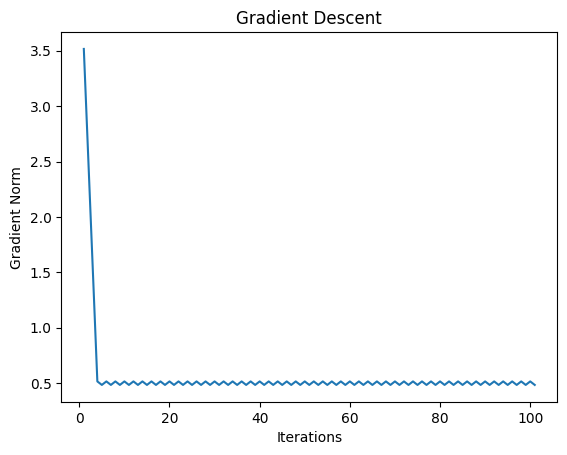

In [15]:
plt.plot(np.arange(1, n_iters+2), grad_hist)
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm")
plt.title("Gradient Descent")

In [16]:
np.linalg.norm(x - x_true_minimizer)

np.float64(0.4841573062220995)